# Sumativa 1 (Fase 2) — Analisis estadistico del Framingham Heart Study
**Estadistica Computacional para la Toma de Decisiones · MDS UNAB**

Integrantes: Eduardo Garrido · Luis Espinosa · Mauricio Ortega · Wilson Arevalo

Repositorio GitHub: https://github.com/GRUPO3MCDI500/mcdi501-estadistica-computacional

**Objetivo:** caracterizar el riesgo coronario a 10 anos (`TenYearCHD`) aplicando estadistica descriptiva,
estimacion por intervalos y pruebas de hipotesis, sustentando conclusiones preliminares con evidencia.
Este notebook regenera las tablas y figuras principales del informe y se ejecuta con el dataset ubicado en
`data/raw/framingham_heart_study.csv` dentro del repositorio.


## 0. Entorno y reproducibilidad
> **Nota:** si al importar pandas aparece un error de incompatibilidad con NumPy 2.x, ejecuta en una celda
> `%pip install "numpy<2"` y reinicia el kernel. Las librerias del stack cientifico de este analisis estan
> pensadas para NumPy 1.x.

In [1]:
import sys, numpy, pandas, scipy, matplotlib
print("Python :", sys.version.split()[0])
print("numpy  :", numpy.__version__)
print("pandas :", pandas.__version__)
print("scipy  :", scipy.__version__)

Python : 3.13.5
numpy  : 2.3.5
pandas : 2.2.3
scipy  : 1.17.0


## 1. Carga de datos y estructura

In [2]:
import numpy as np, pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

# Carga reproducible: se prueban rutas comunes para ejecutar desde la raiz del repo,
# desde la carpeta del notebook o desde una entrega local de Canvas.
DATA_CANDIDATES = [
    Path("data/raw/framingham_heart_study.csv"),
    Path("../../data/raw/framingham_heart_study.csv"),
    Path("framingham_heart_study.csv"),
    Path("framingham heart study.csv"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontro el dataset. Ubicarlo como data/raw/framingham_heart_study.csv "
        "o en la misma carpeta del notebook."
    )

df = pd.read_csv(DATA_PATH)
print("Archivo cargado:", DATA_PATH)
print("Dimensiones:", df.shape)
df.head()


Archivo cargado: ../../data/raw/framingham_heart_study.csv
Dimensiones: (4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


## 2. Clasificacion de variables y calidad de datos
El tipo de variable condiciona que medidas y pruebas son validas.

In [4]:
nominales = ["male","currentSmoker","BPMeds","prevalentStroke","prevalentHyp","diabetes","TenYearCHD"]
ordinales = ["education"]
discretas = ["age","cigsPerDay"]
continuas = ["totChol","sysBP","diaBP","BMI","heartRate","glucose"]
numericas = discretas + continuas

pd.DataFrame({"variable": df.columns,
              "tipo": ["Cual. nominal" if x in nominales else "Cual. ordinal" if x in ordinales
                       else "Cuant. discreta" if x in discretas else "Cuant. continua" for x in df.columns]})

,variable,tipo
0,male,Cual. nominal
1,age,Cuant. discreta
2,education,Cual. ordinal
3,currentSmoker,Cual. nominal
4,cigsPerDay,Cuant. discreta
5,BPMeds,Cual. nominal
6,prevalentStroke,Cual. nominal
7,prevalentHyp,Cual. nominal
8,diabetes,Cual. nominal
9,totChol,Cuant. continua


In [5]:
# Reporte de calidad: faltantes, duplicados, balance
faltantes = df.isna().sum(); faltantes = faltantes[faltantes>0].sort_values(ascending=False)
print("Faltantes por variable:")
print(faltantes.to_frame("n").assign(pct=lambda d:(100*d.n/len(df)).round(2)))
print(f"\nFilas con algun NA: {df.isna().any(axis=1).sum()} ({100*df.isna().any(axis=1).mean():.2f}%)")
print("Duplicados:", df.duplicated().sum())
print(f"Prevalencia CHD: {100*df['TenYearCHD'].mean():.2f}%  (clase desbalanceada)")

Faltantes por variable:
              n   pct
glucose     388  9.15
education   105  2.48
BPMeds       53  1.25
totChol      50  1.18
cigsPerDay   29  0.68
BMI          19  0.45
heartRate     1  0.02

Filas con algun NA: 582 (13.73%)
Duplicados: 0
Prevalencia CHD: 15.19%  (clase desbalanceada)


### 2.1 Chequeo de consistencia de dominios y rangos
Se verifica que las variables binarias/ordinales tengan codigos esperados y que las variables clinicas no presenten valores imposibles simples (por ejemplo, negativos). Los valores extremos plausibles se documentan como atipicos y se analizan con graficos, no se eliminan automaticamente.

In [6]:
# Validacion basica de consistencia: dominios codificados y rangos simples
expected_domains = {
    "male": {0, 1},
    "currentSmoker": {0, 1},
    "BPMeds": {0, 1},
    "prevalentStroke": {0, 1},
    "prevalentHyp": {0, 1},
    "diabetes": {0, 1},
    "TenYearCHD": {0, 1},
    "education": {1, 2, 3, 4},
}

domain_issues = []
for col, allowed in expected_domains.items():
    observed = set(df[col].dropna().astype(int).unique())
    unexpected = observed - allowed
    if unexpected:
        domain_issues.append({"variable": col, "valores_fuera_dominio": sorted(unexpected)})

range_checks = {
    "age": df["age"].between(0, 120),
    "cigsPerDay": df["cigsPerDay"].dropna().ge(0),
    "totChol": df["totChol"].dropna().gt(0),
    "sysBP": df["sysBP"].dropna().gt(0),
    "diaBP": df["diaBP"].dropna().gt(0),
    "BMI": df["BMI"].dropna().gt(0),
    "heartRate": df["heartRate"].dropna().gt(0),
    "glucose": df["glucose"].dropna().gt(0),
}
range_issues = [col for col, ok in range_checks.items() if not bool(ok.all())]

print("Variables con codigos fuera de dominio:", domain_issues if domain_issues else "No se detectan")
print("Variables con rangos imposibles simples:", range_issues if range_issues else "No se detectan")
print("Nota: maximos elevados en glucosa, colesterol y presion se tratan como valores atipicos plausibles; no se eliminan en esta fase.")


Variables con codigos fuera de dominio: No se detectan
Variables con rangos imposibles simples: No se detectan
Nota: maximos elevados en glucosa, colesterol y presion se tratan como valores atipicos plausibles; no se eliminan en esta fase.


## 3. Estadistica descriptiva — variables numericas (ID1.2)
Tendencia central, dispersion y forma.

In [7]:
resumen = df[numericas].describe().T
resumen["CV_%"] = (100*df[numericas].std()/df[numericas].mean()).round(2)
resumen["asimetria"] = df[numericas].skew().round(3)
resumen["curtosis"] = df[numericas].kurtosis().round(3)
resumen.round(2)

,count,mean,std,min,25%,50%,75%,max,CV_%,asimetria,curtosis
age,4240.0,49.58,8.57,32.00,42.00,49.0,56.00,70.0,17.29,0.23,-0.99
cigsPerDay,4211.0,9.01,11.92,0.00,0.00,0.0,20.00,70.0,132.38,1.25,1.02
totChol,4190.0,236.70,44.59,107.00,206.00,234.0,263.00,696.0,18.84,0.87,4.13
sysBP,4240.0,132.35,22.03,83.50,117.00,128.0,144.00,295.0,16.65,1.14,2.16
diaBP,4240.0,82.90,11.91,48.00,75.00,82.0,90.00,142.5,14.37,0.71,1.27
BMI,4221.0,25.80,4.08,15.54,23.07,25.4,28.04,56.8,15.81,0.98,2.66
heartRate,4239.0,75.88,12.03,44.00,68.00,75.0,83.00,143.0,15.85,0.64,0.91
glucose,3852.0,81.96,23.95,40.00,71.00,78.0,87.00,394.0,29.23,6.22,58.70


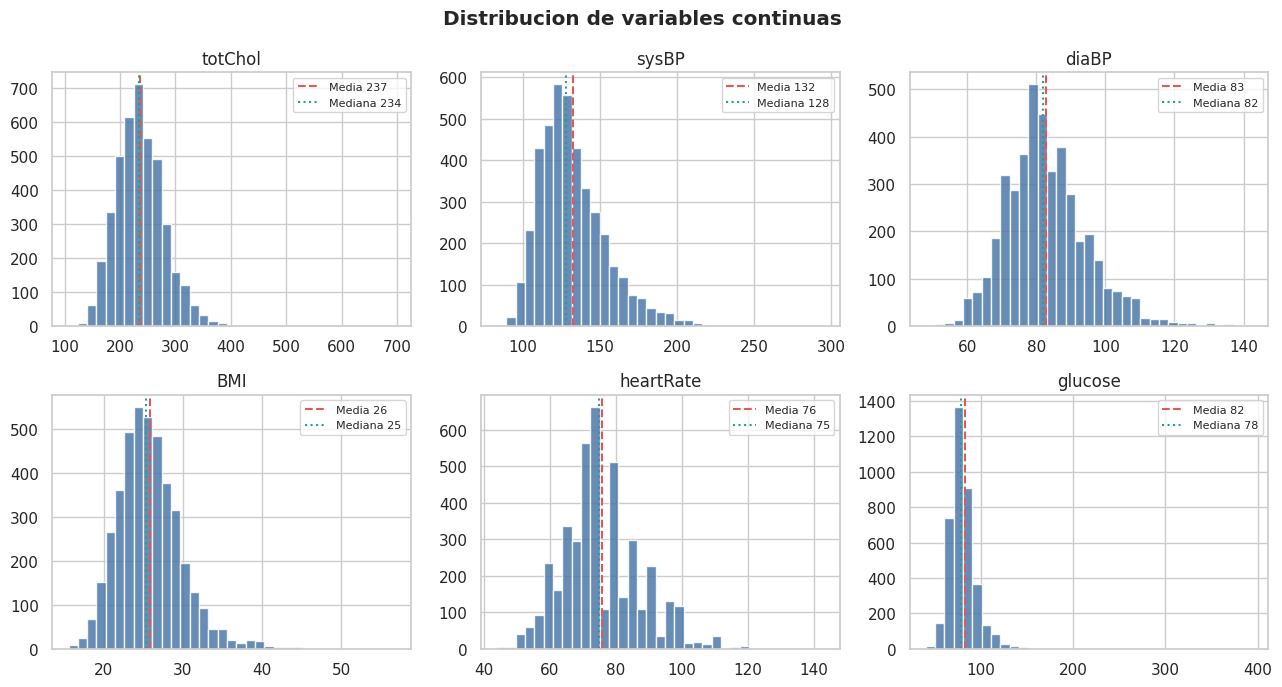

In [8]:
fig, axes = plt.subplots(2,3, figsize=(13,7))
for ax,col in zip(axes.ravel(), continuas):
    s = df[col].dropna()
    ax.hist(s, bins=35, color="#4C78A8", edgecolor="white", alpha=.85)
    ax.axvline(s.mean(), color="#E45756", ls="--", label=f"Media {s.mean():.0f}")
    ax.axvline(s.median(), color="#2A9D8F", ls=":", label=f"Mediana {s.median():.0f}")
    ax.set_title(col); ax.legend(fontsize=8)
plt.suptitle("Distribucion de variables continuas", fontweight="bold"); plt.tight_layout(); plt.show()

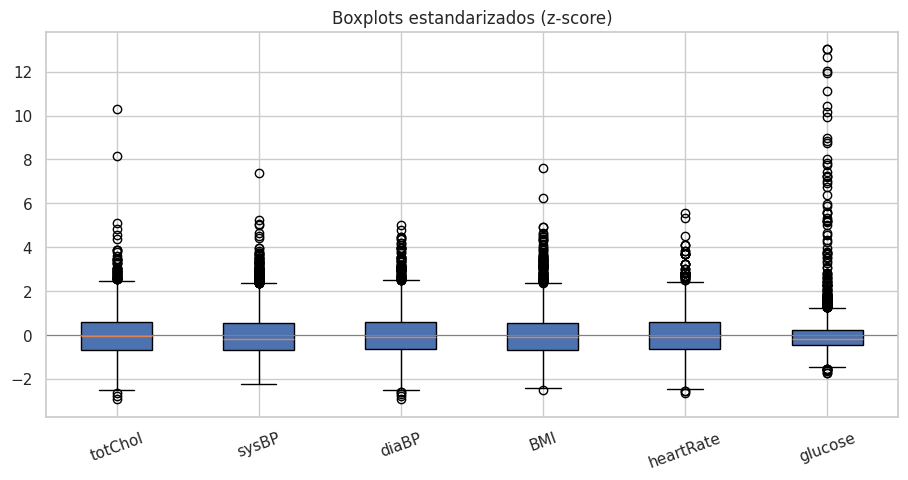

In [9]:
# Boxplots estandarizados (dispersion + outliers)
fig, ax = plt.subplots(figsize=(11,5))
ax.boxplot([(df[c].dropna()-df[c].mean())/df[c].std() for c in continuas], tick_labels=continuas, patch_artist=True)
ax.axhline(0, color="grey", lw=.8); ax.set_title("Boxplots estandarizados (z-score)")
plt.xticks(rotation=20); plt.show()

## 4. Estadistica descriptiva — variables categoricas (ID1.2)
Frecuencias absolutas y relativas.

In [10]:
for c in nominales+ordinales:
    ab = df[c].value_counts().sort_index()
    rel = (100*ab/ab.sum()).round(2)
    print(f"--- {c} ---")
    print(pd.concat([ab.rename("n"), rel.rename("%")], axis=1), "\n")

--- male ---
         n      %
male             
0     2420  57.08
1     1820  42.92 

--- currentSmoker ---
                  n      %
currentSmoker             
0              2145  50.59
1              2095  49.41 

--- BPMeds ---
           n      %
BPMeds             
0.0     4063  97.04
1.0      124   2.96 

--- prevalentStroke ---
                    n      %
prevalentStroke             
0                4215  99.41
1                  25   0.59 

--- prevalentHyp ---
                 n      %
prevalentHyp             
0             2923  68.94
1             1317  31.06 

--- diabetes ---
             n      %
diabetes             
0         4131  97.43
1          109   2.57 

--- TenYearCHD ---
               n      %
TenYearCHD             
0           3596  84.81
1            644  15.19 

--- education ---
              n      %
education             
1.0        1720  41.60
2.0        1253  30.30
3.0         689  16.66
4.0         473  11.44 



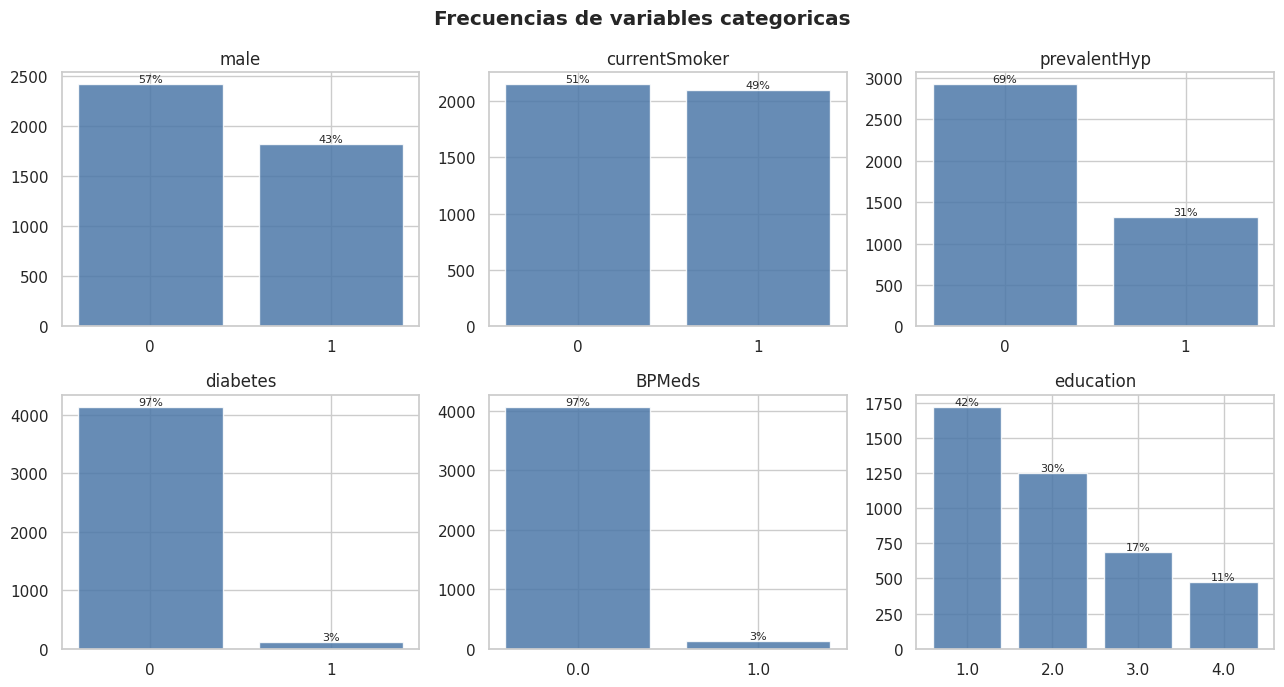

In [11]:
# Graficos de barras de las categoricas principales
fig, axes = plt.subplots(2,3, figsize=(13,7))
for ax,c in zip(axes.ravel(), ["male","currentSmoker","prevalentHyp","diabetes","BPMeds","education"]):
    ab = df[c].value_counts().sort_index(); tot = ab.sum()
    bars = ax.bar(ab.index.astype(str), ab.values, color="#4C78A8", alpha=.85, edgecolor="white")
    for b,v in zip(bars, ab.values): ax.text(b.get_x()+b.get_width()/2, v, f"{100*v/tot:.0f}%", ha="center", va="bottom", fontsize=8)
    ax.set_title(c)
plt.suptitle("Frecuencias de variables categoricas", fontweight="bold"); plt.tight_layout(); plt.show()

## 5. Analisis bivariado
Correlacion (numericas) y prevalencia por grupos. **Correlacion != causalidad.**

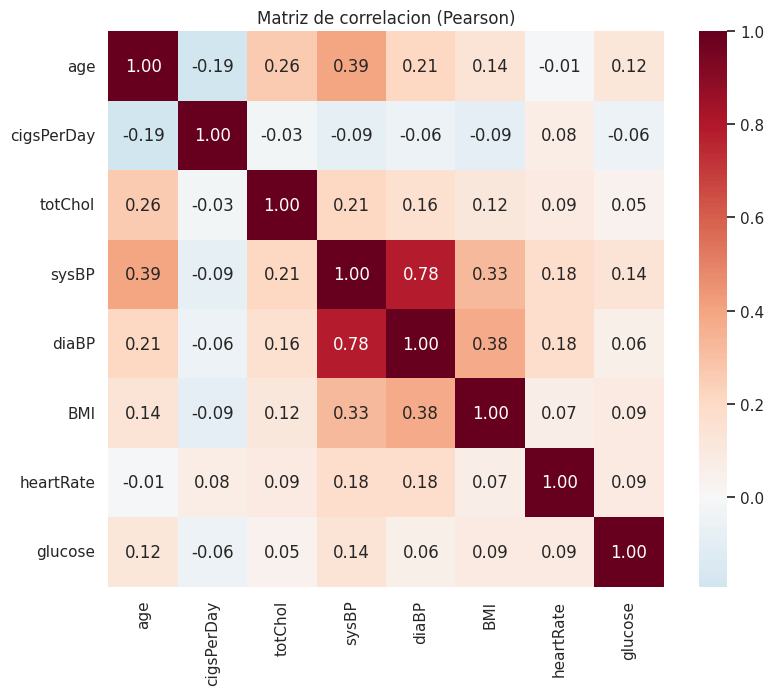

In [12]:
plt.figure(figsize=(8.5,7))
sns.heatmap(df[numericas].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Matriz de correlacion (Pearson)"); plt.tight_layout(); plt.show()

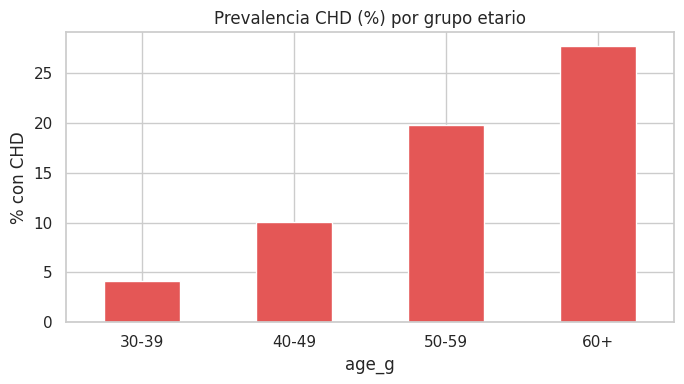

In [13]:
df["age_g"] = pd.cut(df["age"], bins=[30,40,50,60,75], right=False, labels=["30-39","40-49","50-59","60+"])
(df.groupby("age_g", observed=True)["TenYearCHD"].mean()*100).plot(kind="bar", color="#E45756", figsize=(7,4),
    title="Prevalencia CHD (%) por grupo etario")
plt.ylabel("% con CHD"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 6. Estimacion puntual e intervalos de confianza (ID1.3)
Media (IC t) para variables continuas y proporcion (IC Wilson) para la prevalencia de CHD.

In [14]:
def ic_media(s, conf=0.95):
    s=s.dropna(); n=len(s); m=s.mean(); se=s.std(ddof=1)/np.sqrt(n)
    t=stats.t.ppf(1-(1-conf)/2, n-1)
    return round(m,2), round(m-t*se,2), round(m+t*se,2), n

print("IC 95% para medias (distribucion t):")
for c in ["sysBP","totChol","BMI","glucose"]:
    m,lo,hi,n = ic_media(df[c]); print(f"  {c:9s} media={m:7}  IC95% [{lo}, {hi}]  (n={n})")

def ic_wilson(x, n, conf=0.95):
    p=x/n; z=stats.norm.ppf(1-(1-conf)/2); den=1+z**2/n
    cen=(p+z**2/(2*n))/den; half=(z*np.sqrt(p*(1-p)/n+z**2/(4*n**2)))/den
    return round(100*p,2), round(100*(cen-half),2), round(100*(cen+half),2)

x=int(df.TenYearCHD.sum()); n=int(df.TenYearCHD.count()); p,lo,hi = ic_wilson(x,n)
print(f"\nPrevalencia CHD = {p}%  IC95% Wilson [{lo}, {hi}]")
print("Limitacion: los IC suponen muestreo aleatorio; los faltantes pueden sesgar si no son aleatorios.")

IC 95% para medias (distribucion t):
  sysBP     media= 132.35  IC95% [131.69, 133.02]  (n=4240)
  totChol   media=  236.7  IC95% [235.35, 238.05]  (n=4190)
  BMI       media=   25.8  IC95% [25.68, 25.92]  (n=4221)
  glucose   media=  81.96  IC95% [81.21, 82.72]  (n=3852)

Prevalencia CHD = 15.19%  IC95% Wilson [14.14, 16.3]
Limitacion: los IC suponen muestreo aleatorio; los faltantes pueden sesgar si no son aleatorios.


## 7. Pruebas de hipotesis (ID1.4)
Se aplican **dos tipos** de prueba segun el tipo de variable, con $\alpha = 0.05$.

### 7.1 Verificacion de supuestos

In [15]:
# Normalidad (Shapiro en submuestra para controlar sensibilidad con n grande) + homogeneidad (Levene)
for c in ["sysBP","age","totChol"]:
    g0 = df.loc[df.TenYearCHD==0, c].dropna(); g1 = df.loc[df.TenYearCHD==1, c].dropna()
    sh0 = stats.shapiro(g0.sample(500, random_state=1)).pvalue
    sh1 = stats.shapiro(g1.sample(500, random_state=1)).pvalue
    lev = stats.levene(g0, g1).pvalue
    print(f"{c:8s} Shapiro p(sinCHD)={sh0:.1e}  p(conCHD)={sh1:.1e}  Levene p={lev:.1e}  (skew {g0.skew():.2f}/{g1.skew():.2f})")
print("\n-> Hay desviacion de normalidad, pero con n~4200 el TLC hace robusta la prueba t.")
print("-> Varianzas distintas en sysBP (Levene<0.05) => usar t de Welch (equal_var=False).")

sysBP    Shapiro p(sinCHD)=2.2e-13  p(conCHD)=5.8e-13  Levene p=8.2e-16  (skew 1.06/1.00)
age      Shapiro p(sinCHD)=4.0e-09  p(conCHD)=3.6e-07  Levene p=5.3e-02  (skew 0.32/-0.25)
totChol  Shapiro p(sinCHD)=2.9e-04  p(conCHD)=1.3e-07  Levene p=8.4e-02  (skew 0.80/1.11)

-> Hay desviacion de normalidad, pero con n~4200 el TLC hace robusta la prueba t.
-> Varianzas distintas en sysBP (Levene<0.05) => usar t de Welch (equal_var=False).


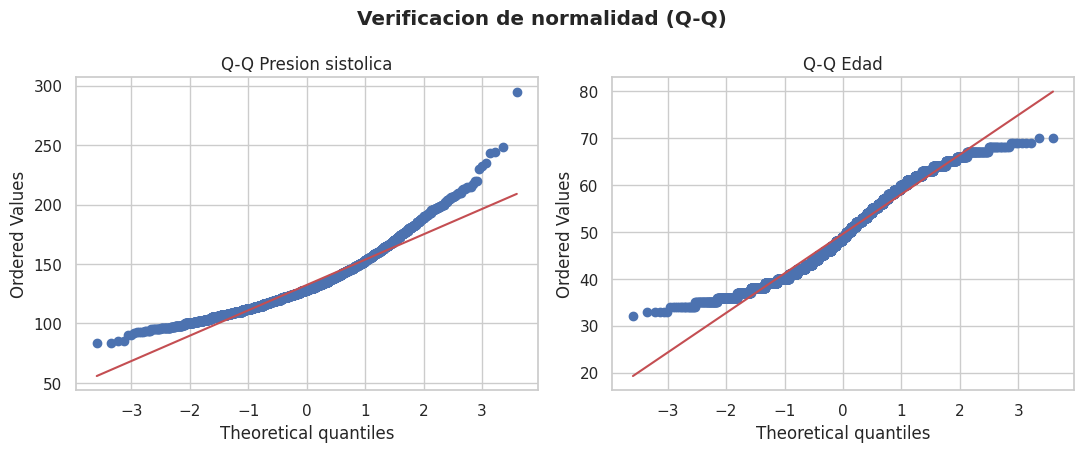

In [16]:
# Q-Q plots
fig, axes = plt.subplots(1,2, figsize=(11,4.6))
for ax,(c,nm) in zip(axes, [("sysBP","Presion sistolica"),("age","Edad")]):
    stats.probplot(df[c].dropna(), dist="norm", plot=ax); ax.set_title(f"Q-Q {nm}")
plt.suptitle("Verificacion de normalidad (Q-Q)", fontweight="bold"); plt.tight_layout(); plt.show()

### 7.2 Prueba A — t de Welch (comparacion de medias)
$H_0: \mu_{CHD}=\mu_{noCHD}$ vs $H_1: \mu_{CHD}\neq\mu_{noCHD}$. Welch no asume varianzas iguales.

In [17]:
def welch(c):
    g0 = df.loc[df.TenYearCHD==0, c].dropna()
    g1 = df.loc[df.TenYearCHD==1, c].dropna()
    t_stat, p = stats.ttest_ind(g1, g0, equal_var=False)

    s0, s1 = g0.var(ddof=1), g1.var(ddof=1)
    n0, n1 = len(g0), len(g1)
    diff = g1.mean() - g0.mean()
    se = np.sqrt(s1/n1 + s0/n0)
    gl = (s1/n1 + s0/n0)**2 / ((s1/n1)**2/(n1-1) + (s0/n0)**2/(n0-1))
    crit = stats.t.ppf(0.975, gl)
    ci = (diff - crit*se, diff + crit*se)
    sp = np.sqrt(((n0-1)*s0+(n1-1)*s1)/(n0+n1-2))
    d = diff/sp

    return dict(
        var=c,
        media_noCHD=round(g0.mean(),2),
        media_CHD=round(g1.mean(),2),
        dif=round(diff,2),
        IC95_dif=f"[{ci[0]:.2f}, {ci[1]:.2f}]",
        t=round(t_stat,3),
        gl=round(gl,1),
        p=p,
        d_cohen=round(d,3),
        decision="Rechaza H0" if p<0.05 else "No rechaza"
    )

pd.DataFrame([welch(c) for c in ["age","sysBP","diaBP","totChol","glucose","BMI","heartRate"]])


,var,media_noCHD,media_CHD,dif,IC95_dif,t,gl,p,d_cohen,decision
0,age,48.76,54.15,5.38,"[4.71, 6.06]",15.592,916.1,8.605387e-49,0.644,Rechaza H0
1,sysBP,130.34,143.62,13.28,"[11.11, 15.45]",12.012,783.8,1.245522e-30,0.617,Rechaza H0
2,diaBP,82.17,86.98,4.81,"[3.67, 5.96]",8.242,800.3,6.893986e-16,0.409,Rechaza H0
3,totChol,235.15,245.39,10.24,"[6.23, 14.25]",5.010,832.3,6.643721e-07,0.230,Rechaza H0
4,glucose,80.68,89.01,8.33,"[4.95, 11.71]",4.841,639.7,1.618413e-06,0.350,Rechaza H0
5,BMI,25.67,26.53,0.86,"[0.48, 1.24]",4.489,815.8,8.170654e-06,0.211,Rechaza H0
6,heartRate,75.76,76.53,0.77,"[-0.26, 1.79]",1.472,877.3,1.414688e-01,0.064,No rechaza


### 7.3 Prueba B — Chi-cuadrado de independencia (categorica x categorica)
$H_0$: el factor es independiente de CHD vs $H_1$: hay asociacion. Supuesto: frecuencias esperadas >= 5.

In [18]:
def chi(c):
    tab = pd.crosstab(df[c], df["TenYearCHD"])
    chi2,p,dof,exp = stats.chi2_contingency(tab)
    V = np.sqrt(chi2/(tab.values.sum()*(min(tab.shape)-1)))   # V de Cramer
    return dict(factor=c, chi2=round(chi2,3), gl=dof, p=p, V_cramer=round(V,3),
                min_esperada=round(exp.min(),1), decision="Rechaza H0" if p<0.05 else "No rechaza")
pd.DataFrame([chi(c) for c in ["prevalentHyp","diabetes","male","currentSmoker"]])

,factor,chi2,gl,p,V_cramer,min_esperada,decision
0,prevalentHyp,132.456,1,1.188961e-30,0.177,200.0,Rechaza H0
1,diabetes,38.482,1,5.525144e-10,0.095,16.6,Rechaza H0
2,male,32.618,1,1.121518e-08,0.088,276.4,Rechaza H0
3,currentSmoker,1.497,1,2.211021e-01,0.019,318.2,No rechaza


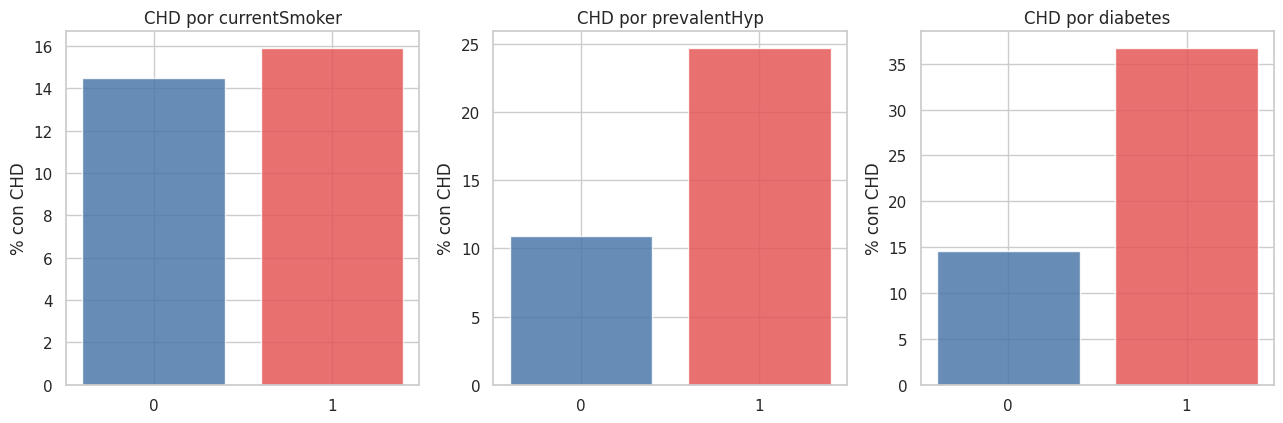

In [19]:
# Visualizacion del chi-cuadrado
fig, axes = plt.subplots(1,3, figsize=(13,4.4))
for ax,c in zip(axes, ["currentSmoker","prevalentHyp","diabetes"]):
    pr = df.groupby(c)["TenYearCHD"].mean()*100
    ax.bar(pr.index.astype(str), pr.values, color=["#4C78A8","#E45756"], alpha=.85)
    ax.set_title(f"CHD por {c}"); ax.set_ylabel("% con CHD")
plt.tight_layout(); plt.show()

## 8. Conclusiones preliminares y proximos pasos
- El riesgo coronario se concentra en mayor **edad, presion arterial y glucosa**, y en presencia de **hipertension o diabetes**.
- **t de Welch:** 6 de 7 variables difieren significativamente; edad y presion sistolica son las mas fuertes (d~0.6). La frecuencia cardiaca no discrimina (p~0.14).
- **Chi-cuadrado:** hipertension (mas fuerte), diabetes y sexo se asocian a CHD; el **tabaquismo actual no resulta significativo** (p~0.22), posible mediacion por otros factores.
- **Limitaciones:** datos observacionales (no causalidad), desbalance de clases y faltantes (glucosa ~9%).

**Proximos pasos (Fase 3):** imputacion de faltantes, manejo del desbalance, modelos de clasificacion (regresion logistica base) con metricas adecuadas (AUC, recall, F1) y analisis multivariado para controlar confusion.

> Correlacion != causalidad · visualizar antes de concluir · el contexto define la interpretacion.